# Eksperimen 14A - Front View Stabilization Revision

Notebook ini dibuat sebagai pendamping hasil terminal untuk Experiment 14A revisi. Training, evaluasi, dan fusion sebaiknya dijalankan dari terminal terlebih dahulu. Setelah itu, jalankan semua cell notebook ini untuk membaca artefak JSON, membuat visualisasi, dan menyusun ringkasan interpretasi.

Side view tetap memakai checkpoint Experiment 13 sebagai kontrol stabil.

In [1]:
# Setup
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
COLORS = {
    'front': '#4C9BE8',
    'side': '#F28E52',
    'average': '#59A14F',
    'adaptive': '#B07AA1',
}

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
RESULTS_DIR = PROJECT_ROOT / 'results'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'

paths = {
    'front_history': RESULTS_DIR / 'front_history_exp14A.json',
    'front_metrics': RESULTS_DIR / 'experiment_14A_front_metrics.json',
    'fusion': RESULTS_DIR / 'fusion_comparison_exp14A.json',
    'front_ckpt': CHECKPOINT_DIR / 'front_best_exp14A.pt',
    'side_ckpt': CHECKPOINT_DIR / 'side_best_exp13_backup.pt',
}

print('Project root:', PROJECT_ROOT)
for name, path in paths.items():
    print(f'{name:14s}: {path.exists()} -> {path}')

Project root: d:\Skripsi\Experiment
front_history : True -> d:\Skripsi\Experiment\results\front_history_exp14A.json
front_metrics : True -> d:\Skripsi\Experiment\results\experiment_14A_front_metrics.json
fusion        : True -> d:\Skripsi\Experiment\results\fusion_comparison_exp14A.json
front_ckpt    : True -> d:\Skripsi\Experiment\checkpoints\front_best_exp14A.pt
side_ckpt     : True -> d:\Skripsi\Experiment\checkpoints\side_best_exp13_backup.pt


## 0. Konfigurasi dan Hipotesis

Experiment 14A revisi dilakukan karena Experiment 14A awal terlalu konservatif: freeze stage 6 dan label smoothing 0.05 membuat model front collapse ke kelas mayoritas `phone_use`. Revisi mengembalikan freeze stage ke 5 dan label smoothing ke 0.0, sambil mempertahankan dropout 0.4 dan weight decay 3e-4 sebagai regularisasi ringan.

In [2]:
# Perbandingan konfigurasi utama: Exp13 vs Exp14A revisi
config_rows = [
    {'parameter': 'learning_rate', 'experiment_13': '3e-5', 'experiment_14A': '3e-5'},
    {'parameter': 'weight_decay', 'experiment_13': '2e-3', 'experiment_14A': '3e-4'},
    {'parameter': 'dropout_front', 'experiment_13': '0.5', 'experiment_14A': '0.4'},
    {'parameter': 'label_smoothing', 'experiment_13': '0.0', 'experiment_14A': '0.0'},
    {'parameter': 'freeze_stage_front', 'experiment_13': '5', 'experiment_14A': '5'},
    {'parameter': 'early_stopping_patience', 'experiment_13': '3', 'experiment_14A': '4'},
    {'parameter': 'batch_size', 'experiment_13': '32', 'experiment_14A': '32'},
    {'parameter': 'max_epoch', 'experiment_13': '30', 'experiment_14A': '30'},
    {'parameter': 'front_rotation_aug', 'experiment_13': 'pipeline current', 'experiment_14A': '68'},
    {'parameter': 'front_color_jitter', 'experiment_13': 'pipeline current', 'experiment_14A': '1.2'},
]
config_df = pd.DataFrame(config_rows)
display(config_df)

,parameter,experiment_13,experiment_14A
0,learning_rate,3e-5,3e-5
1,weight_decay,2e-3,3e-4
2,dropout_front,0.5,0.4
3,label_smoothing,0.0,0.0
4,freeze_stage_front,5,5
5,early_stopping_patience,3,4
6,batch_size,32,32
7,max_epoch,30,30
8,front_rotation_aug,pipeline current,68
9,front_color_jitter,pipeline current,1.2


## 0.5. Command Terminal

Notebook ini tidak menjalankan training otomatis. Command terminal yang sesuai untuk menghasilkan artefak 14A adalah:

In [3]:
commands = [
    r'.\.venv\Scripts\python.exe -m src.train --view front --experiment experiment_14A',
    r'.\.venv\Scripts\python.exe -m src.evaluate --view front --checkpoint checkpoints\front_best_exp14A.pt',
    r'.\.venv\Scripts\python.exe -m src.fusion --front-checkpoint checkpoints\front_best_exp14A.pt --side-checkpoint checkpoints\side_best_exp13_backup.pt',
]
print('\n'.join(commands))

.\.venv\Scripts\python.exe -m src.train --view front --experiment experiment_14A
.\.venv\Scripts\python.exe -m src.evaluate --view front --checkpoint checkpoints\front_best_exp14A.pt
.\.venv\Scripts\python.exe -m src.fusion --front-checkpoint checkpoints\front_best_exp14A.pt --side-checkpoint checkpoints\side_best_exp13_backup.pt


## 1. Load Hasil Eksperimen

In [4]:
def load_json(path):
    if not path.exists():
        print(f'MISSING: {path}')
        return None
    return json.loads(path.read_text(encoding='utf-8'))

history = load_json(paths['front_history'])
front_metrics = load_json(paths['front_metrics'])
fusion = load_json(paths['fusion'])

hist_df = pd.DataFrame(history) if history else pd.DataFrame()
if not hist_df.empty:
    hist_df.index = hist_df.index + 1
    hist_df.index.name = 'epoch'

print('history loaded:', not hist_df.empty)
print('front metrics loaded:', front_metrics is not None)
print('fusion loaded:', fusion is not None)

history loaded: True
front metrics loaded: True
fusion loaded: True


## 2. Ringkasan Front View

In [5]:
if front_metrics:
    front_summary_keys = [
        'best_epoch', 'val_macro_f1',
        'train_loss_at_best_epoch', 'validation_loss_at_best_epoch',
        'train_validation_loss_gap_at_best_epoch',
        'test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_macro_f1',
        'ece_binary', 'brier_score',
    ]
    display(pd.Series({k: front_metrics.get(k) for k in front_summary_keys}, name='front_exp14A'))
else:
    print('Front metrics belum tersedia.')

best_epoch                                 9.000000
val_macro_f1                               0.725810
train_loss_at_best_epoch                   0.473535
validation_loss_at_best_epoch              0.517363
train_validation_loss_gap_at_best_epoch    0.043829
test_accuracy                              0.863640
test_precision_macro                       0.771830
test_recall_macro                          0.761110
test_macro_f1                              0.766260
ece_binary                                 0.125130
brier_score                                0.113110
Name: front_exp14A, dtype: float64

## 3. History Training

In [6]:
if not hist_df.empty:
    display(hist_df)
else:
    print('History belum tersedia.')

,train_loss,train_accuracy,val_loss,val_macro_f1,val_accuracy,val_precision_macro,val_recall_macro,train_val_loss_gap,lr
epoch,,,,,,,,,
1,0.68932,0.74053,0.63331,0.57331,0.80000,0.58249,0.56791,-0.05602,0.000030
2,0.62853,0.76989,0.61716,0.60011,0.81778,0.61750,0.59047,-0.01137,0.000030
3,0.59312,0.78314,0.61332,0.64747,0.80000,0.63660,0.66461,0.02020,0.000030
4,0.54896,0.81061,0.59023,0.64845,0.80889,0.64123,0.65776,0.04127,0.000030
5,0.52988,0.82481,0.55668,0.65328,0.84889,0.69335,0.63297,0.02680,0.000030
6,0.50284,0.84186,0.54337,0.69549,0.84000,0.69114,0.70026,0.04053,0.000030
7,0.50961,0.81723,0.52457,0.71596,0.83556,0.69722,0.74600,0.01496,0.000030
8,0.48857,0.81913,0.52586,0.70060,0.82667,0.68333,0.72867,0.03729,0.000030
9,0.47353,0.83523,0.51736,0.72581,0.84444,0.70847,0.75123,0.04383,0.000030


## 4. Kurva Training

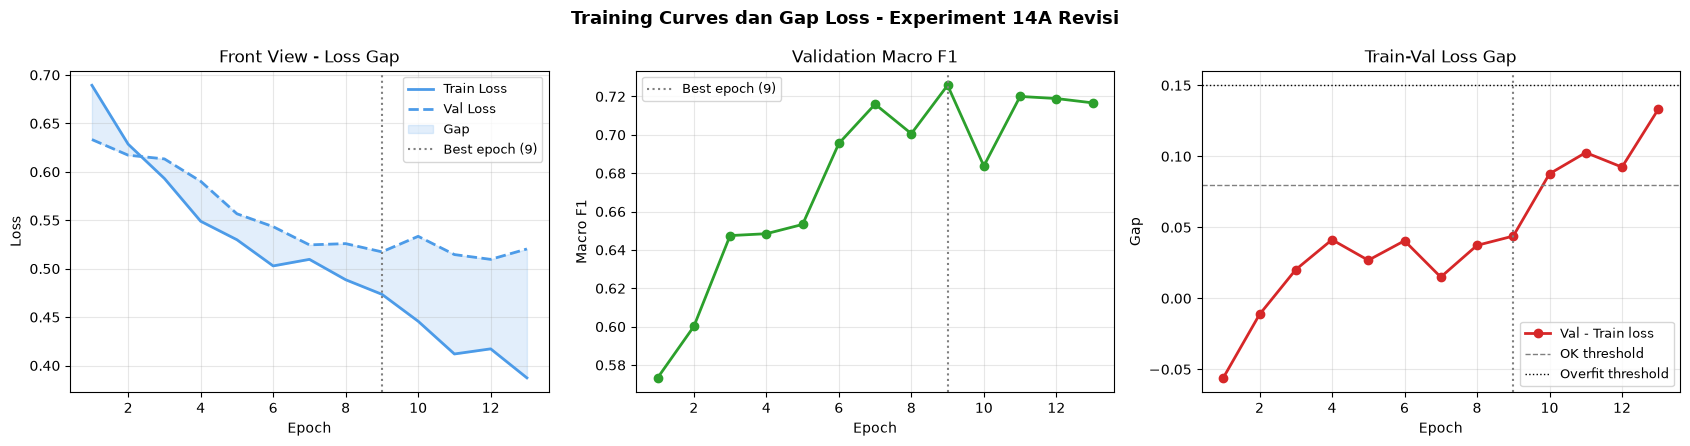

In [7]:
if not hist_df.empty:
    epochs = hist_df.index.to_numpy()
    train_losses = hist_df['train_loss'].to_numpy()
    val_losses = hist_df['val_loss'].to_numpy()
    gaps = val_losses - train_losses
    best_epoch = int(hist_df['val_macro_f1'].idxmax())

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    fig.suptitle('Training Curves dan Gap Loss - Experiment 14A Revisi', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, train_losses, label='Train Loss', color=COLORS['front'], linewidth=2)
    axes[0].plot(epochs, val_losses, label='Val Loss', color=COLORS['front'], linewidth=2, linestyle='--')
    axes[0].fill_between(epochs, train_losses, val_losses, color=COLORS['front'], alpha=0.16, label='Gap')
    axes[0].axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')
    axes[0].set_title('Front View - Loss Gap')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=9)

    axes[1].plot(epochs, hist_df['val_macro_f1'], marker='o', color='tab:green', linewidth=2)
    axes[1].axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')
    axes[1].set_title('Validation Macro F1')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=9)

    axes[2].plot(epochs, gaps, marker='o', color='tab:red', linewidth=2, label='Val - Train loss')
    axes[2].axhline(0.08, color='gray', linestyle='--', linewidth=1, label='OK threshold')
    axes[2].axhline(0.15, color='black', linestyle=':', linewidth=1, label='Overfit threshold')
    axes[2].axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5)
    axes[2].set_title('Train-Val Loss Gap')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Gap')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=9)

    plt.tight_layout()
else:
    print('History belum tersedia untuk plot.')

## 5. Analisis Gap Train-Val Loss

In [8]:
if not hist_df.empty:
    train_losses = hist_df['train_loss'].to_numpy()
    val_losses = hist_df['val_loss'].to_numpy()
    gaps = val_losses - train_losses
    best_epoch = int(hist_df['val_macro_f1'].idxmax())
    best_idx = best_epoch - 1
    final_gap = float(gaps[-1])
    status = 'OVERFIT' if final_gap > 0.15 else ('OK' if final_gap < 0.08 else 'BORDERLINE')

    df_gap_summary = pd.DataFrame([{
        'View': 'Front',
        'Train Loss (akhir)': round(float(train_losses[-1]), 5),
        'Val Loss (akhir)': round(float(val_losses[-1]), 5),
        'Gap akhir': round(final_gap, 5),
        'Gap di best epoch': round(float(gaps[best_idx]), 5),
        'Gap maksimum': round(float(gaps.max()), 5),
        'Best epoch': best_epoch,
        'Status': status,
    }]).set_index('View')
    display(df_gap_summary.style.set_caption('Ringkasan Gap Loss - Experiment 14A Revisi'))

    gap_epoch_df = hist_df[['train_loss', 'val_loss', 'train_val_loss_gap', 'val_macro_f1']].copy()
    gap_epoch_df['gap_status'] = pd.cut(
        gap_epoch_df['train_val_loss_gap'],
        bins=[-float('inf'), 0.08, 0.15, float('inf')],
        labels=['OK', 'BORDERLINE', 'OVERFIT']
    )
    display(gap_epoch_df)
else:
    print('History belum tersedia.')

,Train Loss (akhir),Val Loss (akhir),Gap akhir,Gap di best epoch,Gap maksimum,Best epoch,Status
View,,,,,,,
Front,0.387260,0.520360,0.133100,0.043830,0.133100,9,BORDERLINE


,train_loss,val_loss,train_val_loss_gap,val_macro_f1,gap_status
epoch,,,,,
1,0.68932,0.63331,-0.05602,0.57331,OK
2,0.62853,0.61716,-0.01137,0.60011,OK
3,0.59312,0.61332,0.02020,0.64747,OK
4,0.54896,0.59023,0.04127,0.64845,OK
5,0.52988,0.55668,0.02680,0.65328,OK
6,0.50284,0.54337,0.04053,0.69549,OK
7,0.50961,0.52457,0.01496,0.71596,OK
8,0.48857,0.52586,0.03729,0.70060,OK
9,0.47353,0.51736,0.04383,0.72581,OK


## 6. Confusion Matrix Front View

,pred_safe,pred_phone
true_safe,24,16
true_phone,14,166


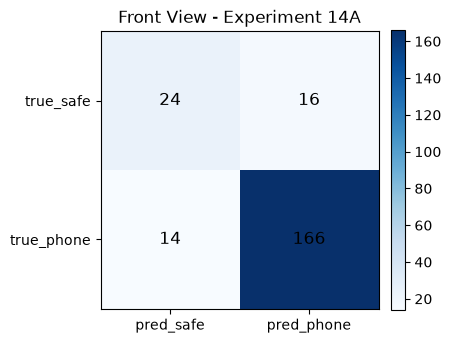

In [9]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1], labels=['pred_safe', 'pred_phone'])
    ax.set_yticks([0, 1], labels=['true_safe', 'true_phone'])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha='center', va='center', color='black', fontsize=12)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

if front_metrics:
    cm_front = front_metrics.get('confusion_matrix', [])
    display(pd.DataFrame(cm_front, index=['true_safe', 'true_phone'], columns=['pred_safe', 'pred_phone']))
    plot_confusion_matrix(cm_front, 'Front View - Experiment 14A')
else:
    print('Front metrics belum tersedia.')

## 7. Classification Report Front View

In [10]:
if front_metrics:
    report = front_metrics.get('classification_report', {})
    report_df = pd.DataFrame(report).T
    display(report_df)
else:
    print('Classification report belum tersedia.')

,precision,recall,f1-score,support
safe_driving,0.631579,0.600000,0.615385,40.000000
phone_use,0.912088,0.922222,0.917127,180.000000
accuracy,0.863636,0.863636,0.863636,0.863636
macro avg,0.771833,0.761111,0.766256,220.000000
weighted avg,0.861086,0.863636,0.862265,220.000000


## 8. Hasil Fusion

In [11]:
if fusion:
    rows = []
    for key, item in fusion.items():
        rows.append({
            'method_key': key,
            'method': item.get('method', key),
            'accuracy': item.get('accuracy'),
            'precision_macro': item.get('precision_macro'),
            'recall_macro': item.get('recall_macro'),
            'f1_macro': item.get('f1_macro'),
        })
    fusion_df = pd.DataFrame(rows).set_index('method_key')
    display(fusion_df)
else:
    fusion_df = pd.DataFrame()
    print('Fusion result belum tersedia.')

,method,accuracy,precision_macro,recall_macro,f1_macro
method_key,,,,,
single_front,Single-view FRONT,0.86364,0.77183,0.76111,0.76626
single_side,Single-view SIDE,0.81364,0.66553,0.60417,0.62023
average_fusion,Average Fusion (50:50),0.89091,0.86565,0.73889,0.78059
adaptive_fusion,Adaptive Fusion (confidence),0.89091,0.86565,0.73889,0.78059


## 9. Confusion Matrix Fusion

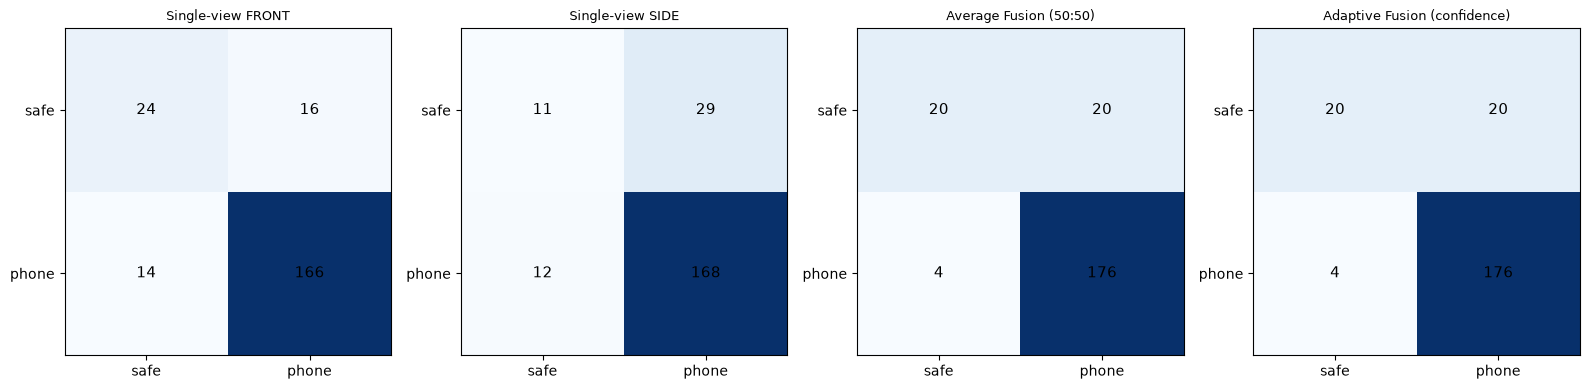

In [12]:
if fusion:
    methods = ['single_front', 'single_side', 'average_fusion', 'adaptive_fusion']
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
    for ax, method in zip(axes, methods):
        cm = fusion[method]['confusion_matrix']
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0, 1], labels=['safe', 'phone'])
        ax.set_yticks([0, 1], labels=['safe', 'phone'])
        ax.set_title(fusion[method].get('method', method), fontsize=9)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i][j], ha='center', va='center', fontsize=11)
    plt.tight_layout()
else:
    print('Fusion result belum tersedia.')

## 10. Perbandingan Macro F1

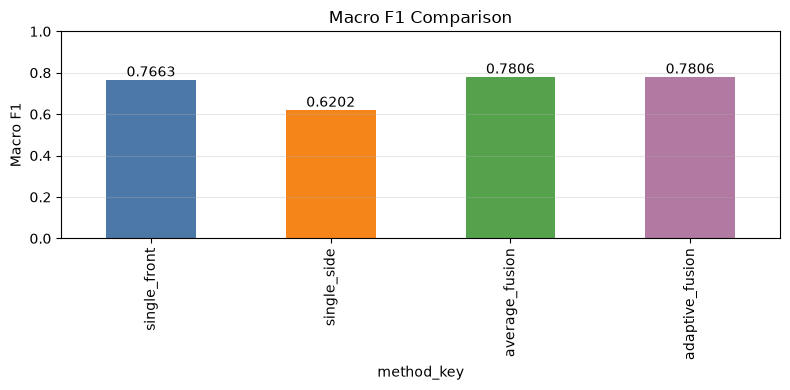

In [13]:
if not fusion_df.empty:
    ax = fusion_df['f1_macro'].plot(kind='bar', figsize=(8, 4), color=['#4c78a8', '#f58518', '#54a24b', '#b279a2'])
    ax.set_title('Macro F1 Comparison')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.grid(True, axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
    plt.tight_layout()
else:
    print('Fusion table belum tersedia.')

## 11. Analisis Kelas Minoritas Safe Driving

,precision,recall,f1,support
class,,,,
safe_driving,0.631579,0.600000,0.615385,40.0
phone_use,0.912088,0.922222,0.917127,180.0


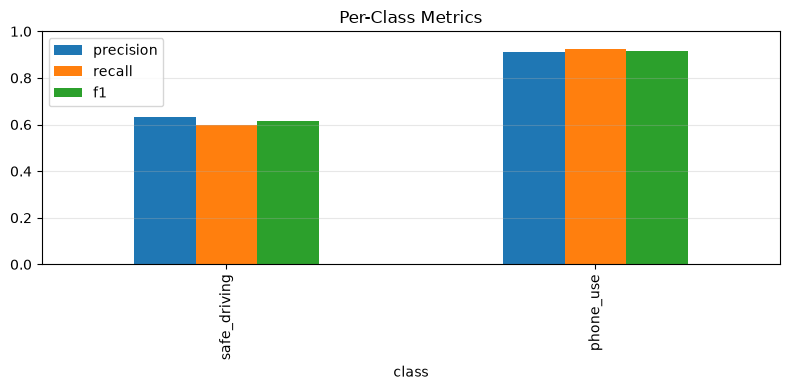

In [14]:
if front_metrics:
    safe = front_metrics['classification_report']['safe_driving']
    phone = front_metrics['classification_report']['phone_use']
    minority_df = pd.DataFrame([
        {'class': 'safe_driving', 'precision': safe['precision'], 'recall': safe['recall'], 'f1': safe['f1-score'], 'support': safe['support']},
        {'class': 'phone_use', 'precision': phone['precision'], 'recall': phone['recall'], 'f1': phone['f1-score'], 'support': phone['support']},
    ]).set_index('class')
    display(minority_df)
    ax = minority_df[['precision', 'recall', 'f1']].plot(kind='bar', figsize=(8, 4))
    ax.set_ylim(0, 1)
    ax.set_title('Per-Class Metrics')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
else:
    print('Front metrics belum tersedia.')

## 12. Kalibrasi Ringkas

In [15]:
if front_metrics:
    ece_val = front_metrics.get('ece_binary')
    bs_val = front_metrics.get('brier_score')
    calib_df = pd.DataFrame([
        {
            'Model': 'Front 14A',
            'ECE': ece_val,
            'Brier Score': bs_val,
            'ECE Status': 'BAIK' if ece_val < 0.05 else ('SEDANG' if ece_val < 0.10 else 'BURUK'),
            'BS Status': 'BAIK' if bs_val < 0.10 else ('SEDANG' if bs_val < 0.20 else 'BURUK'),
        }
    ]).set_index('Model')
    display(calib_df.style.set_caption('Diagnostik Kalibrasi - Test Set (Experiment 14A)'))
else:
    print('Calibration metrics belum tersedia.')

,ECE,Brier Score,ECE Status,BS Status
Model,,,,
Front 14A,0.125130,0.113110,BURUK,SEDANG


## 12b. Reliability Diagram Front View

In [16]:
def compute_ece_from_probs(probs, labels, n_bins=10):
    probs = np.asarray(probs)
    labels = np.asarray(labels)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(probs)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_acc = labels[mask].mean()
        bin_conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)

def compute_brier_from_probs(probs, labels):
    probs = np.asarray(probs)
    labels = np.asarray(labels)
    return float(np.mean((probs - labels) ** 2))

def reliability_diagram(ax, probs, labels, title, color, n_bins=10):
    probs = np.asarray(probs)
    labels = np.asarray(labels)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_conf, bin_acc = [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_conf.append(probs[mask].mean())
        bin_acc.append(labels[mask].mean())

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.55, label='Perfect calibration')
    ax.bar(bin_conf, bin_acc, width=0.08, alpha=0.45, color=color, label='Actual fraction')
    ax.plot(bin_conf, bin_acc, 'o-', color=color, linewidth=2, label='Calibration curve')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Mean Predicted Probability (phone_use)')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

print('Fungsi reliability diagram siap.')

Fungsi reliability diagram siap.


In [17]:
# Inferensi probabilitas front 14A untuk reliability diagram.
# Ini hanya membaca checkpoint dan test loader; tidak menulis ulang hasil evaluasi/fusion.
try:
    import torch
    from src.evaluate import load_trained_model, predict_test
    from src.dataset import get_dataloader

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_front, _ = load_trained_model('front', device, checkpoint_path=str(paths['front_ckpt']))
    test_loader = get_dataloader('front', 'test')
    labels_front, preds_front, probs_front = predict_test(model_front, test_loader, device)
    labels_front = np.asarray(labels_front, dtype=float)
    probs_front = np.asarray(probs_front, dtype=float)

    ece_front_nb = compute_ece_from_probs(probs_front, labels_front)
    bs_front_nb = compute_brier_from_probs(probs_front, labels_front)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    reliability_diagram(
        ax,
        probs_front,
        labels_front,
        f'Front 14A\nECE={ece_front_nb:.4f} | Brier={bs_front_nb:.4f}',
        COLORS['front'],
    )
    plt.tight_layout()
    out_path = RESULTS_DIR / 'exp14A_reliability_diagram.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)
except Exception as exc:
    print('Reliability diagram tidak dapat dibuat:', exc)


Reliability diagram tidak dapat dibuat: No module named 'src'


## 13. Perbandingan Dengan Baseline Catatan Exp13

In [18]:
# Angka Exp13 diambil dari ringkasan ablation lokal yang sudah digunakan sebagai baseline pembanding.
baseline = {
    'front_test_macro_f1': 0.77399,
    'front_safe_recall': 0.675,
    'front_loss_gap_best': 0.16315,
    'fusion_macro_f1': 0.78412,
}

if front_metrics and fusion:
    compare_df = pd.DataFrame([
        {'metric': 'front_test_macro_f1', 'experiment_13': baseline['front_test_macro_f1'], 'experiment_14A': front_metrics['test_macro_f1'], 'delta_14A_minus_13': front_metrics['test_macro_f1'] - baseline['front_test_macro_f1']},
        {'metric': 'front_safe_recall', 'experiment_13': baseline['front_safe_recall'], 'experiment_14A': front_metrics['classification_report']['safe_driving']['recall'], 'delta_14A_minus_13': front_metrics['classification_report']['safe_driving']['recall'] - baseline['front_safe_recall']},
        {'metric': 'front_loss_gap_best', 'experiment_13': baseline['front_loss_gap_best'], 'experiment_14A': front_metrics['train_validation_loss_gap_at_best_epoch'], 'delta_14A_minus_13': front_metrics['train_validation_loss_gap_at_best_epoch'] - baseline['front_loss_gap_best']},
        {'metric': 'fusion_macro_f1', 'experiment_13': baseline['fusion_macro_f1'], 'experiment_14A': fusion['average_fusion']['f1_macro'], 'delta_14A_minus_13': fusion['average_fusion']['f1_macro'] - baseline['fusion_macro_f1']},
    ])
    display(compare_df)
else:
    print('Data 14A belum lengkap untuk dibandingkan.')

,metric,experiment_13,experiment_14A,delta_14A_minus_13
0,front_test_macro_f1,0.77399,0.766260,-0.007730
1,front_safe_recall,0.67500,0.600000,-0.075000
2,front_loss_gap_best,0.16315,0.043829,-0.119321
3,fusion_macro_f1,0.78412,0.780590,-0.003530


## 14. Kesimpulan Otomatis

In [19]:
if front_metrics and fusion:
    safe_recall = front_metrics['classification_report']['safe_driving']['recall']
    front_f1 = front_metrics['test_macro_f1']
    gap = front_metrics['train_validation_loss_gap_at_best_epoch']
    fusion_f1 = fusion['average_fusion']['f1_macro']

    print('Kesimpulan Experiment 14A revisi')
    print(f'- Front Macro F1       : {front_f1:.5f}')
    print(f'- Safe recall          : {safe_recall:.5f}')
    print(f'- Loss gap best epoch  : {gap:.5f}')
    print(f'- Average fusion F1    : {fusion_f1:.5f}')
    print()
    if front_f1 >= 0.76 and safe_recall >= 0.60 and gap < 0.08 and fusion_f1 >= 0.78:
        print('Status: berhasil sebagai kandidat stabil front view.')
    else:
        print('Status: perlu ditinjau ulang terhadap indikator keberhasilan.')
else:
    print('Artefak hasil belum lengkap.')

Kesimpulan Experiment 14A revisi
- Front Macro F1       : 0.76626
- Safe recall          : 0.60000
- Loss gap best epoch  : 0.04383
- Average fusion F1    : 0.78059

Status: berhasil sebagai kandidat stabil front view.


## 15. Ekspor Ringkasan Notebook

In [20]:
if front_metrics and fusion:
    notebook_summary = {
        'experiment': 'experiment_14A',
        'front_best_epoch': front_metrics.get('best_epoch'),
        'front_val_macro_f1': front_metrics.get('val_macro_f1'),
        'front_test_macro_f1': front_metrics.get('test_macro_f1'),
        'front_safe_recall': front_metrics['classification_report']['safe_driving']['recall'],
        'front_loss_gap_best': front_metrics.get('train_validation_loss_gap_at_best_epoch'),
        'average_fusion_macro_f1': fusion['average_fusion']['f1_macro'],
        'adaptive_fusion_macro_f1': fusion['adaptive_fusion']['f1_macro'],
    }
    out_path = RESULTS_DIR / 'experiment_14A_notebook_summary.json'
    out_path.write_text(json.dumps(notebook_summary, indent=2), encoding='utf-8')
    print('Saved:', out_path)
    display(pd.Series(notebook_summary))
else:
    print('Tidak menulis summary karena artefak belum lengkap.')

Saved: d:\Skripsi\Experiment\results\experiment_14A_notebook_summary.json


experiment                  experiment_14A
front_best_epoch                         9
front_val_macro_f1                 0.72581
front_test_macro_f1                0.76626
front_safe_recall                      0.6
front_loss_gap_best               0.043829
average_fusion_macro_f1            0.78059
adaptive_fusion_macro_f1           0.78059
dtype: object

## Catatan Interpretasi

- Experiment 14A revisi dipakai sebagai kandidat stabil karena menyeimbangkan performa dan gap loss.
- Front Macro F1 sedikit di bawah Experiment 13, tetapi train-validation loss gap jauh lebih sehat.
- Safe driving tidak collapse: 24 dari 40 sampel safe dikenali benar pada test set.
- Average fusion dan adaptive fusion tetap identik pada hasil ini, sesuai pola eksperimen sebelumnya.